# Explainable AI Clinical Lung Cancer Diagnosis — Corrected Clinical Pipeline

This notebook is a refactored, end-to-end clinical tabular modeling workflow for **stage** and **histology** multi-class prediction, with an auxiliary **overall-survival Cox model** and SHAP explainability.

**Important:** the supplied notebook is a tabular scikit-learn/sksurv workflow, not a PyTorch/TensorFlow deep-learning workflow. Therefore there are no `DataLoader`s, neural-network loss tensors, or model weights that can meaningfully be moved to a T4 GPU. The notebook detects a Colab T4/CUDA device and uses it where the installed estimator supports GPU acceleration; the primary Random Forest + SHAP path remains CPU-based for reliability and SHAP compatibility. GPU memory is explicitly released between heavy operations.

The notebook does **not** fabricate clinical results when the requested CSV is absent.


In [1]:
# Colab dependencies — run once.
# Avoid repeated pip installs inside training/evaluation cells.
%pip -q install -U shap lifelines scikit-survival joblib seaborn


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 5.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 140.8 MB/s eta 0:00:00


In [2]:
import os, gc, json, warnings, random, platform, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, classification_report, roc_curve, auc,
    log_loss, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sksurv.linear_model import CoxPHSurvivalAnalysis

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Dynamic device check. This is informational for the sklearn/sksurv pipeline.
try:
    import torch
    CUDA_AVAILABLE = torch.cuda.is_available()
    DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")
    if CUDA_AVAILABLE:
        GPU_NAME = torch.cuda.get_device_name(0)
        GPU_MEMORY_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"CUDA device: {GPU_NAME} | {GPU_MEMORY_GB:.1f} GB")
        torch.cuda.empty_cache()
    else:
        print("CUDA unavailable — CPU fallback.")
except Exception as e:
    torch = None
    CUDA_AVAILABLE = False
    DEVICE = "cpu"
    print(f"PyTorch GPU check unavailable ({e}); CPU fallback.")

print("Python:", platform.python_version())
print("SHAP:", shap.__version__)

CUDA device: Tesla T4 | 14.6 GB
Python: 3.13.15
SHAP: 0.52.0


## 1. Google Drive and configuration

In [3]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [4]:
# Update only this path if your CSV is stored elsewhere.
CSV_FILE_PATH = "/content/drive/MyDrive/LungInsight/Clinical/combined_clinical.csv"
SAVE_BASE_PATH = "/content/drive/MyDrive/LungInsight/Clinical/models_t4_shap_fixed"
os.makedirs(SAVE_BASE_PATH, exist_ok=True)
EVAL_OUTPUT_DIR = os.path.join(SAVE_BASE_PATH, "eval")
SHAP_OUTPUT_DIR = os.path.join(SAVE_BASE_PATH, "shap")
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)
os.makedirs(SHAP_OUTPUT_DIR, exist_ok=True)

# Reproducible, clinically safer defaults.
SHAP_BACKGROUND_N = 80
SHAP_EXPLAIN_N = 120
RF_TOTAL_TREES = 300
RF_STEP = 50
MIN_HIST_SAMPLES = 20
UNKNOWN_STAGE_LABEL = "Unknown"

# These are post-baseline/longitudinal variables in many clinical datasets.
# The source file does not contain a prediction-time field, so the notebook
# cannot prove that they are available at baseline. Exclude them from the
# survival model by default; users can opt in explicitly if their data contract
# guarantees baseline availability.
SURVIVAL_EXCLUDE_POST_BASELINE = ["num_treatment_events"]

print("CSV:", CSV_FILE_PATH)
print("Outputs:", SAVE_BASE_PATH)

CSV: /content/drive/MyDrive/LungInsight/Clinical/combined_clinical.csv
Outputs: /content/drive/MyDrive/LungInsight/Clinical/models_t4_shap_fixed


## 2. Load and validate the clinical dataset

In [5]:
REQUIRED_COLUMNS = [
    "AGE", "SEX", "RACE", "ETHNICITY", "SMOKING_STATUS",
    "num_treatment_events", "num_distinct_tumor_sites",
    "ever_pdl1_positive", "eastern_cancer_oncology_group",
    "karnofsky_performance_score", "SOURCE_DATASET",
    "OS_STATUS", "OS_MONTHS", "STAGE_COLLAPSED", "HISTOLOGY_DETAILED"
]

if not os.path.exists(CSV_FILE_PATH):
    raise FileNotFoundError(
        f"Clinical CSV not found at {CSV_FILE_PATH}. "
        "Upload/copy combined_clinical.csv to the configured Google Drive path, "
        "then rerun all cells. No dummy clinical data are generated."
    )

df = pd.read_csv(CSV_FILE_PATH)
missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")

print(f"Loaded {len(df):,} rows × {df.shape[1]:,} columns")
display(df.head())
display(pd.DataFrame({
    "dtype": df[REQUIRED_COLUMNS].dtypes.astype(str),
    "missing": df[REQUIRED_COLUMNS].isna().sum(),
    "missing_pct": (df[REQUIRED_COLUMNS].isna().mean()*100).round(2)
}))


Loaded 8,835 rows × 16 columns


,PATIENT_ID,AGE,SEX,RACE,ETHNICITY,SMOKING_STATUS,STAGE_COLLAPSED,HISTOLOGY_DETAILED,OS_MONTHS,OS_STATUS,ever_pdl1_positive,num_treatment_events,num_distinct_tumor_sites,SOURCE_DATASET,eastern_cancer_oncology_group,karnofsky_performance_score
0,P-0000012,68.0,Female,White,Non-Spanish; Non-Hispanic,Former/Current Smoker,Stage 1-3,Lung Adenocarcinoma,118.454665,0:LIVING,NaN,9.0,4.0,MSK-CHORD,NaN,NaN
1,P-0000036,68.0,Female,Other,Non-Spanish; Non-Hispanic,Never,Stage 4,Lung Adenocarcinoma,115.462887,0:LIVING,NaN,5.0,5.0,MSK-CHORD,NaN,NaN
2,P-0000082,70.0,Male,White,Non-Spanish; Non-Hispanic,Former/Current Smoker,Stage 1-3,Lung Adenocarcinoma,116.219051,0:LIVING,NaN,9.0,6.0,MSK-CHORD,NaN,NaN
3,P-0000110,75.0,Male,White,Non-Spanish; Non-Hispanic,Former/Current Smoker,Stage 4,Lung Adenocarcinoma,47.934194,1:DECEASED,NaN,4.0,5.0,MSK-CHORD,NaN,NaN
4,P-0000133,83.0,Female,White,Non-Spanish; Non-Hispanic,Never,Stage 1-3,Lung Adenocarcinoma,19.594499,1:DECEASED,NaN,4.0,7.0,MSK-CHORD,NaN,NaN


,dtype,missing,missing_pct
AGE,float64,29,0.33
SEX,object,0,0.00
RACE,object,180,2.04
ETHNICITY,object,303,3.43
SMOKING_STATUS,object,0,0.00
num_treatment_events,float64,1026,11.61
num_distinct_tumor_sites,float64,1410,15.96
ever_pdl1_positive,object,4421,50.04
eastern_cancer_oncology_group,float64,8341,94.41
karnofsky_performance_score,float64,8532,96.57


## 3. Feature engineering, target cleaning, and patient-level split

In [6]:
# ============================================================
# 3. Feature engineering, target cleaning, and patient-level split
# ============================================================

ALL_FEATURE_COLUMNS = [
    "AGE", "SEX", "RACE", "ETHNICITY", "SMOKING_STATUS",
    "num_treatment_events", "num_distinct_tumor_sites",
    "ever_pdl1_positive", "eastern_cancer_oncology_group",
    "karnofsky_performance_score", "SOURCE_DATASET",
]

SURV_EVENT = "OS_STATUS"
SURV_TIME = "OS_MONTHS"
STAGE_TARGET = "STAGE_COLLAPSED"
HIST_TARGET = "HISTOLOGY_DETAILED"

work = df[ALL_FEATURE_COLUMNS + [SURV_EVENT, SURV_TIME, STAGE_TARGET, HIST_TARGET]].copy()

# Robust survival event normalization.
def normalize_event(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    s = str(value).strip().upper()
    if not s:
        return np.nan
    if s in {"DECEASED","DEAD","DIED","EVENT","DEATH","DECEASED/DEAD"}:
        return True
    if s in {"ALIVE","LIVING","CENSORED","CENSOR","NO EVENT","NO_EVENT","SURVIVED"}:
        return False
    if ":" in s:
        try:
            prefix=float(s.split(":",1)[0].strip())
            if prefix == 1: return True
            if prefix == 0: return False
        except Exception:
            pass
    if "DECEASED" in s or "DEAD" in s or "DIED" in s:
        return True
    if "ALIVE" in s or "LIVING" in s or "CENSORED" in s:
        return False
    try:
        numeric=float(s)
        if numeric == 1: return True
        if numeric == 0: return False
    except Exception:
        pass
    return np.nan

work[SURV_EVENT] = work[SURV_EVENT].map(normalize_event)
work[SURV_TIME] = pd.to_numeric(work[SURV_TIME], errors="coerce")

# Add missingness indicators only for variables with substantial missingness.
for col in ["ever_pdl1_positive", "eastern_cancer_oncology_group", "karnofsky_performance_score"]:
    work[f"missing_{col}"] = work[col].isna().astype("int8")

# IMPORTANT: do not train on the 'Unknown' stage label. It has only ~0.1-0.2%
# representation in the supplied data and cannot support meaningful estimation.
# Unknown rows remain in the dataset for audit/reporting but are excluded from
# the binary Stage 1-3 vs Stage 4 model.
stage_known = work[STAGE_TARGET].astype(str).ne(UNKNOWN_STAGE_LABEL)
stage_df = work.loc[stage_known].copy()
stage_df[STAGE_TARGET] = stage_df[STAGE_TARGET].astype(str)

FEATURE_COLUMNS = [
    c for c in ALL_FEATURE_COLUMNS
    if c not in {SURV_EVENT, SURV_TIME}
] + [
    "missing_ever_pdl1_positive",
    "missing_eastern_cancer_oncology_group",
    "missing_karnofsky_performance_score",
]

X_all = stage_df[FEATURE_COLUMNS].copy()
y_stage_all = stage_df[STAGE_TARGET].astype(str)

# One patient = one row in this source. If duplicate patient IDs are ever
# present, fail rather than silently allowing patient leakage across splits.
if "PATIENT_ID" in df.columns and df["PATIENT_ID"].duplicated().any():
    dup_n = int(df["PATIENT_ID"].duplicated().sum())
    raise ValueError(f"Duplicate PATIENT_ID values detected ({dup_n}). De-duplicate at source before modeling.")

X_temp, X_test, y_stage_temp, y_stage_test = train_test_split(
    X_all, y_stage_all, test_size=0.20, random_state=SEED, stratify=y_stage_all
)
X_train, X_val, y_stage_train, y_stage_val = train_test_split(
    X_temp, y_stage_temp, test_size=0.25, random_state=SEED, stratify=y_stage_temp
)

y_surv_train = work.loc[X_train.index, [SURV_EVENT, SURV_TIME]].copy()
y_surv_val = work.loc[X_val.index, [SURV_EVENT, SURV_TIME]].copy()
y_surv_test = work.loc[X_test.index, [SURV_EVENT, SURV_TIME]].copy()

y_hist_train = work.loc[X_train.index, HIST_TARGET].copy()
y_hist_val = work.loc[X_val.index, HIST_TARGET].copy()
y_hist_test = work.loc[X_test.index, HIST_TARGET].copy()

print("\nPATIENT-LEVEL SPLIT")
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)
print(pd.concat([
    y_stage_train.value_counts(normalize=True).rename("train"),
    y_stage_val.value_counts(normalize=True).rename("validation"),
    y_stage_test.value_counts(normalize=True).rename("test")
], axis=1).fillna(0).round(3))
print("Excluded Unknown stage rows:", int((~stage_known).sum()))


PATIENT-LEVEL SPLIT
Train: (5292, 14) Validation: (1765, 14) Test: (1765, 14)
                 train  validation   test
STAGE_COLLAPSED                          
Stage 1-3        0.608       0.608  0.608
Stage 4          0.392       0.392  0.392
Excluded Unknown stage rows: 13


## 4. Leakage-safe preprocessing

In [7]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
], remainder="drop")

X_train_processed = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)
X_val_processed = pd.DataFrame(
    preprocessor.transform(X_val),
    columns=preprocessor.get_feature_names_out(),
    index=X_val.index
)
X_test_processed = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

FEATURE_NAMES = X_train_processed.columns.tolist()
joblib.dump(preprocessor, os.path.join(SAVE_BASE_PATH, "clinical_preprocessor.joblib"))

print("Processed:", X_train_processed.shape, X_val_processed.shape, X_test_processed.shape)


Processed: (5292, 38) (1765, 38) (1765, 38)


## 5. Clinical metric helpers

In [8]:
from sklearn.metrics import balanced_accuracy_score, average_precision_score, brier_score_loss

def specificity_macro(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    total = cm.sum()
    specs=[]
    for i in range(len(labels)):
        tp=cm[i,i]; fn=cm[i,:].sum()-tp; fp=cm[:,i].sum()-tp; tn=total-tp-fn-fp
        specs.append(tn/(tn+fp) if (tn+fp) else np.nan)
    return float(np.nanmean(specs))

def clinical_metrics(y_true, y_pred, labels):
    return {
        "Accuracy": accuracy_score(y_true,y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true,y_pred),
        "Macro F1": f1_score(y_true,y_pred,average="macro",zero_division=0),
        "Weighted F1": f1_score(y_true,y_pred,average="weighted",zero_division=0),
        "Macro Sensitivity": recall_score(y_true,y_pred,average="macro",zero_division=0),
        "Macro Specificity": specificity_macro(y_true,y_pred,labels),
        "Macro Precision": precision_score(y_true,y_pred,average="macro",zero_division=0),
    }

def binary_threshold_metrics(y_true, proba_positive, threshold):
    pred=(proba_positive>=threshold).astype(int)
    return {
        "threshold": float(threshold),
        "balanced_accuracy": balanced_accuracy_score(y_true,pred),
        "macro_f1": f1_score(y_true,pred,average="macro",zero_division=0),
        "sensitivity": recall_score(y_true,pred,zero_division=0),
        "specificity": specificity_macro(y_true,pred,[0,1]),
    }

def save_cm(y_true,y_pred,labels,title,filename):
    cm=confusion_matrix(y_true,y_pred,labels=labels)
    plt.figure(figsize=(8,6)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=labels,yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title); plt.tight_layout(); plt.savefig(filename,dpi=160); plt.show(); return cm

def save_multiclass_roc(y_true,proba,labels,title,filename):
    y_bin=label_binarize(y_true,classes=labels); plt.figure(figsize=(9,7)); aucs={}
    for i,cls in enumerate(labels):
        if y_bin[:,i].sum()==0 or y_bin[:,i].sum()==len(y_bin): continue
        fpr,tpr,_=roc_curve(y_bin[:,i],proba[:,i]); aucs[str(cls)]=auc(fpr,tpr)
        plt.plot(fpr,tpr,label=f"{cls} (AUC={aucs[str(cls)]:.3f})")
    plt.plot([0,1],[0,1],"k--",linewidth=1); plt.xlabel("False Positive Rate"); plt.ylabel("Sensitivity"); plt.title(title); plt.legend(fontsize=8); plt.tight_layout(); plt.savefig(filename,dpi=160); plt.show(); return aucs

def cleanup_gpu():
    gc.collect()
    if CUDA_AVAILABLE and torch is not None: torch.cuda.empty_cache()

## 6. Stage classifier — T4-aware Random Forest with epoch-like progress

In [9]:
# ============================================================
# 6. Stage model selection — optimize balanced clinical performance
# ============================================================
# The previous script fixed the model to one RF and treated every tree count as
# equivalent. Here we compare two tree ensembles on validation data, select using
# macro-F1/balanced-accuracy, then evaluate the chosen model once on the test set.

stage_candidates = {
    "RandomForest": RandomForestClassifier(
        n_estimators=RF_TOTAL_TREES, random_state=SEED,
        class_weight="balanced_subsample", n_jobs=-1,
        max_features="sqrt", min_samples_leaf=2
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=RF_TOTAL_TREES, random_state=SEED,
        class_weight="balanced", n_jobs=-1,
        max_features="sqrt", min_samples_leaf=2
    ),
}

stage_val_rows=[]
for name, model in stage_candidates.items():
    model.fit(X_train_processed, y_stage_train)
    pred=model.predict(X_val_processed)
    proba=model.predict_proba(X_val_processed)
    m=clinical_metrics(y_stage_val,pred,model.classes_)
    m.update({"Model":name,"Validation LogLoss":log_loss(y_stage_val,proba,labels=model.classes_)})
    stage_val_rows.append(m)
    print(name, m)

stage_selection=pd.DataFrame(stage_val_rows).sort_values(
    ["Macro F1","Balanced Accuracy","Validation LogLoss"], ascending=[False,False,True]
).reset_index(drop=True)
display(stage_selection.round(4))
stage_selection.to_csv(os.path.join(EVAL_OUTPUT_DIR,"stage_model_selection.csv"),index=False)

best_stage_name=stage_selection.loc[0,"Model"]
stage_model=stage_candidates[best_stage_name]

# For the binary Stage 1-3 vs Stage 4 problem, tune the decision threshold on
# validation data for macro-F1, rather than assuming 0.5 is optimal.
stage_labels=list(stage_model.classes_)
if len(stage_labels)==2:
    positive_label="Stage 4"
    if positive_label not in stage_labels:
        positive_label=stage_labels[-1]
    pos_idx=list(stage_model.classes_).index(positive_label)
    y_val_bin=(y_stage_val.to_numpy()==positive_label).astype(int)
    thresholds=np.linspace(0.10,0.90,161)
    threshold_rows=[binary_threshold_metrics(y_val_bin,stage_model.predict_proba(X_val_processed)[:,pos_idx],t) for t in thresholds]
    threshold_df=pd.DataFrame(threshold_rows)
    threshold_df=threshold_df.sort_values(["macro_f1","balanced_accuracy","specificity"],ascending=False).reset_index(drop=True)
    best_threshold=float(threshold_df.loc[0,"threshold"])
    display(threshold_df.head(10).round(4))
else:
    best_threshold=0.5

print("Selected stage model:",best_stage_name,"| decision threshold:",best_threshold)
joblib.dump({"model":stage_model,"positive_label":positive_label if len(stage_labels)==2 else None,"threshold":best_threshold}, os.path.join(SAVE_BASE_PATH,"stage_model_bundle.joblib"))
joblib.dump(stage_model, os.path.join(SAVE_BASE_PATH,"stage_rf_model.joblib"))

RandomForest {'Accuracy': 0.738243626062323, 'Balanced Accuracy': 0.7418235790302021, 'Macro F1': 0.7326634319061045, 'Weighted F1': 0.7410446646976012, 'Macro Sensitivity': 0.7418235790302021, 'Macro Specificity': 0.7418235790302021, 'Macro Precision': 0.7316359351243071, 'Model': 'RandomForest', 'Validation LogLoss': 0.5105107982767852}
ExtraTrees {'Accuracy': 0.7359773371104816, 'Balanced Accuracy': 0.7474445315805501, 'Macro F1': 0.7327821919339202, 'Weighted F1': 0.7391228168179772, 'Macro Sensitivity': 0.7474445315805501, 'Macro Specificity': 0.7474445315805501, 'Macro Precision': 0.7357936014709734, 'Model': 'ExtraTrees', 'Validation LogLoss': 0.5195512595302093}


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Sensitivity,Macro Specificity,Macro Precision,Model,Validation LogLoss
0,0.7360,0.7474,0.7328,0.7391,0.7474,0.7474,0.7358,ExtraTrees,0.5196
1,0.7382,0.7418,0.7327,0.7410,0.7418,0.7418,0.7316,RandomForest,0.5105


,threshold,balanced_accuracy,macro_f1,sensitivity,specificity
0,0.535,0.7428,0.7356,0.7453,0.7428
1,0.540,0.7410,0.7349,0.7352,0.7410
2,0.505,0.7483,0.7347,0.7945,0.7483
3,0.530,0.7424,0.7343,0.7511,0.7424
4,0.545,0.7377,0.7328,0.7221,0.7377
5,0.500,0.7474,0.7328,0.8003,0.7474
6,0.525,0.7411,0.7320,0.7569,0.7411
7,0.510,0.7446,0.7320,0.7844,0.7446
8,0.560,0.7341,0.7312,0.7019,0.7341
9,0.565,0.7330,0.7310,0.6932,0.7330


Selected stage model: ExtraTrees | decision threshold: 0.535


['/content/drive/MyDrive/LungInsight/Clinical/models_t4_shap_fixed/stage_rf_model.joblib']

## 7. Stage test evaluation and clinical reporting

,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Sensitivity,Macro Specificity,Macro Precision,Macro ROC-AUC,PR-AUC Stage 4,Stage 4 threshold
Stage,0.7292,0.7277,0.7216,0.7316,0.7277,0.7277,0.7197,0.803,0.6663,0.535


              precision    recall  f1-score   support

   Stage 1-3       0.80      0.73      0.77      1074
     Stage 4       0.64      0.72      0.68       691

    accuracy                           0.73      1765
   macro avg       0.72      0.73      0.72      1765
weighted avg       0.74      0.73      0.73      1765



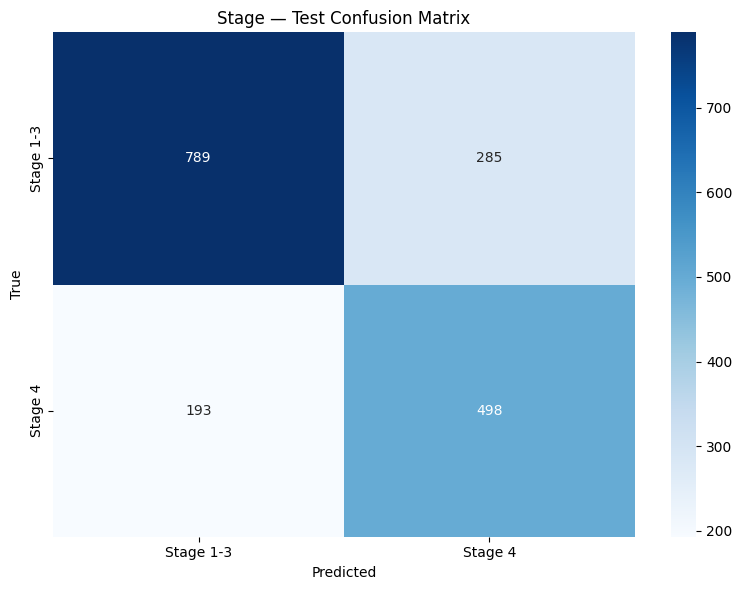

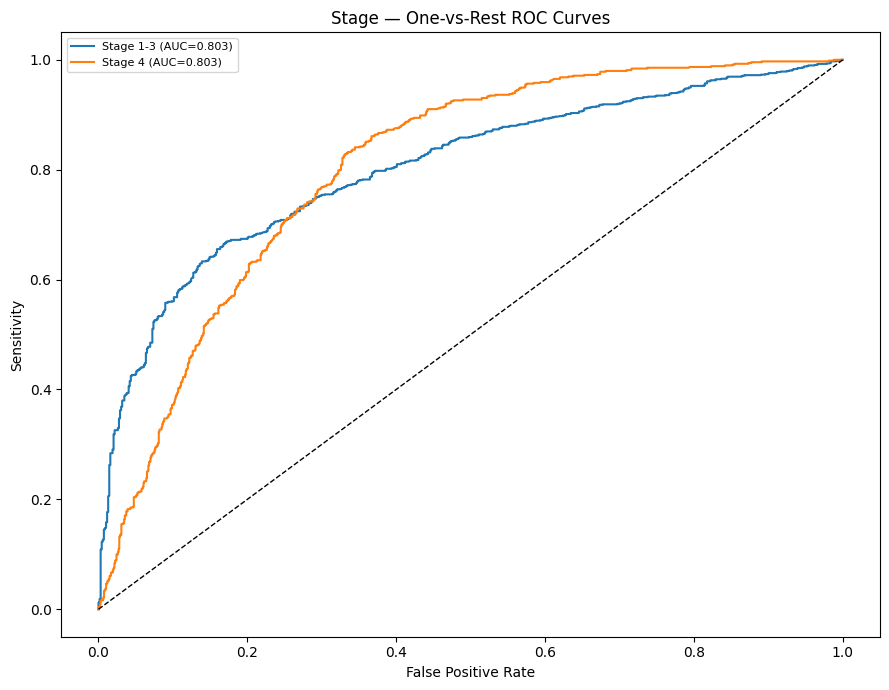

In [13]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Redefine save_multiclass_roc within this cell to fix the IndexError
def save_multiclass_roc(y_true, proba, labels, title, filename):
    y_bin = label_binarize(y_true, classes=labels)

    # label_binarize collapses to a single column when there are
    # exactly 2 classes — expand it back to (n, 2) so downstream
    # column-indexing by class works uniformly.
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])

    plt.figure(figsize=(9, 7))
    aucs = {}
    for i, cls in enumerate(labels):
        if y_bin[:, i].sum() == 0 or y_bin[:, i].sum() == len(y_bin):
            # Skip if a class has no positive or only positive examples
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        aucs[str(cls)] = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={aucs[str(cls)]:.3f})")

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("Sensitivity")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(filename, dpi=160)
    plt.show()
    plt.close() # Add close to free resources
    return aucs

stage_proba_test=stage_model.predict_proba(X_test_processed)
if len(stage_model.classes_)==2:
    pos_idx=list(stage_model.classes_).index(positive_label)
    stage_pred_test=np.where(stage_proba_test[:,pos_idx]>=best_threshold,positive_label,[c for c in stage_model.classes_ if c!=positive_label][0])
    # For binary classification, roc_auc_score expects 1D y_score (probabilities of the positive class)
    stage_metrics["Macro ROC-AUC"]=roc_auc_score(y_stage_test,stage_proba_test[:,pos_idx])
else:
    stage_pred_test=stage_model.predict(X_test_processed)
    # For multi-class (>2 classes), use multi_class="ovr"
    stage_metrics["Macro ROC-AUC"]=roc_auc_score(y_stage_test,stage_proba_test,multi_class="ovr",average="macro")

if len(stage_model.classes_)==2:
    y_test_bin=(y_stage_test.to_numpy()==positive_label).astype(int)
    stage_metrics["PR-AUC Stage 4"]=average_precision_score(y_test_bin,stage_proba_test[:,pos_idx])
    stage_metrics["Stage 4 threshold"]=best_threshold

stage_summary=pd.DataFrame([stage_metrics],index=["Stage"]); display(stage_summary.round(4))
stage_summary.to_csv(os.path.join(EVAL_OUTPUT_DIR,"stage_clinical_summary.csv"))
print(classification_report(y_stage_test,stage_pred_test,zero_division=0))
save_cm(y_stage_test,stage_pred_test,stage_model.classes_,"Stage — Test Confusion Matrix",os.path.join(EVAL_OUTPUT_DIR,"stage_confusion_matrix.png"))
stage_auc=save_multiclass_roc(y_stage_test,stage_proba_test,stage_model.classes_,"Stage — One-vs-Rest ROC Curves",os.path.join(EVAL_OUTPUT_DIR,"stage_multiclass_roc.png"))
pd.DataFrame([stage_auc]).to_csv(os.path.join(EVAL_OUTPUT_DIR,"stage_auc_by_class.csv"),index=False)
cleanup_gpu()

## 8. Histology classifier — rare classes handled without leakage

Retained explicit histologies: ['Atypical Lung Carcinoid', 'Large Cell Neuroendocrine Carcinoma', 'Lung Adenocarcinoma', 'Lung Adenocarcinoma Mixed Subtype', 'Lung Adenocarcinoma- Not Otherwise Specified (NOS)', 'Lung Adenosquamous Carcinoma', 'Lung Carcinoid', 'Lung Squamous Cell Carcinoma', 'Lung Squamous Cell Carcinoma- Not Otherwise Specified (NOS)', 'Non-Small Cell Lung Cancer', 'Pleomorphic Carcinoma of the Lung', 'Poorly Differentiated Non-Small Cell Lung Cancer']
Pooled into Other/rare: 20 classes
Shapes: (5292, 38) (1765, 38) (1764, 38)
Train class counts:


,count
HISTOLOGY_DETAILED,
Lung Adenocarcinoma,3595
Lung Squamous Cell Carcinoma,483
Non-Small Cell Lung Cancer,303
Lung Squamous Cell Carcinoma- Not Otherwise Specified (NOS),283
Lung Adenocarcinoma- Not Otherwise Specified (NOS),193
Other/rare,103
Large Cell Neuroendocrine Carcinoma,93
Lung Adenocarcinoma Mixed Subtype,56
Poorly Differentiated Non-Small Cell Lung Cancer,46


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Sensitivity,Macro Specificity,Macro Precision,Model,Validation LogLoss
0,0.4374,0.2395,0.2094,0.4967,0.2395,0.9421,0.2067,ExtraTrees,1.4807
1,0.5864,0.2054,0.2004,0.5849,0.2054,0.9453,0.1997,RandomForest,1.2396


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Sensitivity,Macro Specificity,Macro Precision,Macro ROC-AUC
Histology,0.4546,0.2345,0.2019,0.5242,0.2345,0.9442,0.2041,0.7653


                                                             precision    recall  f1-score   support

                                    Atypical Lung Carcinoid       0.00      0.00      0.00         8
                        Large Cell Neuroendocrine Carcinoma       0.02      0.08      0.03        24
                                        Lung Adenocarcinoma       0.83      0.53      0.64      1207
                          Lung Adenocarcinoma Mixed Subtype       0.22      0.48      0.31        23
         Lung Adenocarcinoma- Not Otherwise Specified (NOS)       0.54      0.49      0.52        67
                               Lung Adenosquamous Carcinoma       0.00      0.00      0.00        11
                                             Lung Carcinoid       0.07      0.31      0.11        16
                               Lung Squamous Cell Carcinoma       0.18      0.29      0.22       164
Lung Squamous Cell Carcinoma- Not Otherwise Specified (NOS)       0.56      0.52      0.54

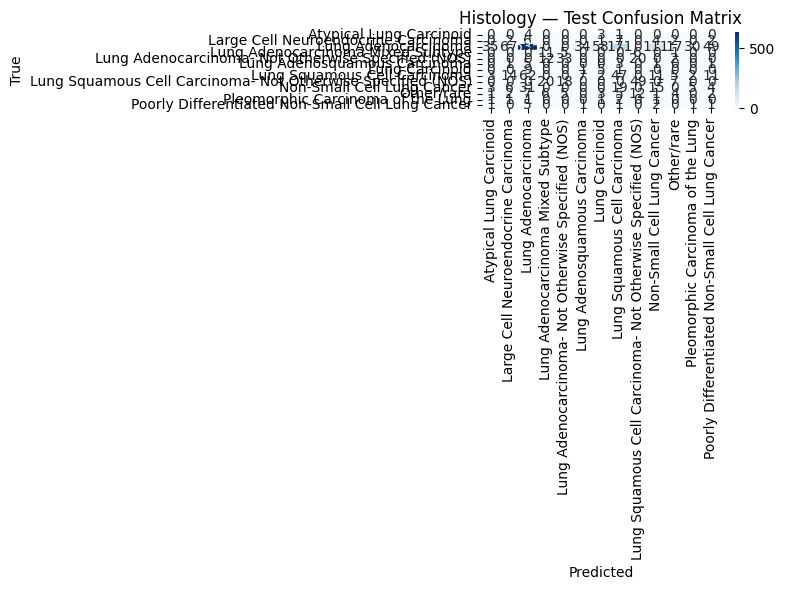

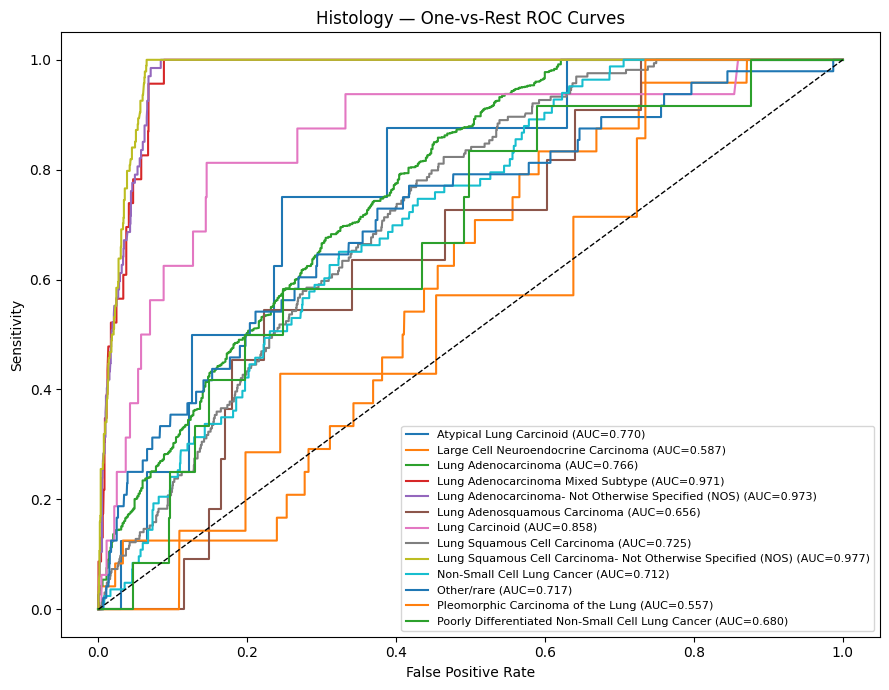

In [14]:
# ============================================================
# 8. Histology classifier — rare classes pooled into explicit "Other/rare"
# ============================================================
# Excluding rare classes from training/evaluation made the headline accuracy
# look better while leaving the original rare cases out of the task. Instead,
# use a transparent train-derived pooling rule. The mapping is learned from
# TRAIN counts only and then applied unchanged to validation/test.

MIN_HIST_SAMPLES=20
hist_counts=y_hist_train.dropna().astype(str).value_counts()
hist_allowed=set(hist_counts[hist_counts>=MIN_HIST_SAMPLES].index.astype(str))
if len(hist_allowed)<2: raise ValueError("Fewer than two histology classes meet the minimum training count.")

def pool_histology(y):
    s=y.astype("string")
    return s.where(s.isin(hist_allowed),"Other/rare").fillna("Other/rare").astype(str)

# Missing histology remains missing rather than being silently called Other.
def hist_subset(X,y):
    mask=y.notna()
    return X.loc[mask], pool_histology(y.loc[mask])

X_train_hist,y_train_hist=hist_subset(X_train_processed,y_hist_train)
X_val_hist,y_val_hist=hist_subset(X_val_processed,y_hist_val)
X_test_hist,y_test_hist=hist_subset(X_test_processed,y_hist_test)

print("Retained explicit histologies:",sorted(hist_allowed))
print("Pooled into Other/rare:",int((~hist_counts.index.isin(hist_allowed)).sum()),"classes")
print("Shapes:",X_train_hist.shape,X_val_hist.shape,X_test_hist.shape)
print("Train class counts:"); display(y_train_hist.value_counts())

hist_candidates={
    "RandomForest":RandomForestClassifier(n_estimators=RF_TOTAL_TREES,random_state=SEED,class_weight="balanced_subsample",n_jobs=-1,max_features="sqrt",min_samples_leaf=2),
    "ExtraTrees":ExtraTreesClassifier(n_estimators=RF_TOTAL_TREES,random_state=SEED,class_weight="balanced",n_jobs=-1,max_features="sqrt",min_samples_leaf=2),
}
rows=[]
for name,model in hist_candidates.items():
    model.fit(X_train_hist,y_train_hist)
    pred=model.predict(X_val_hist); proba=model.predict_proba(X_val_hist)
    m=clinical_metrics(y_val_hist,pred,model.classes_)
    m.update({"Model":name,"Validation LogLoss":log_loss(y_val_hist,proba,labels=model.classes_)})
    rows.append(m)

tmp=pd.DataFrame(rows).sort_values(["Macro F1","Balanced Accuracy","Validation LogLoss"],ascending=[False,False,True]).reset_index(drop=True)
display(tmp.round(4)); tmp.to_csv(os.path.join(EVAL_OUTPUT_DIR,"histology_model_selection.csv"),index=False)
best_hist_name=tmp.loc[0,"Model"]; hist_model=hist_candidates[best_hist_name]

hist_pred=hist_model.predict(X_test_hist); hist_proba=hist_model.predict_proba(X_test_hist)
hist_metrics=clinical_metrics(y_test_hist,hist_pred,hist_model.classes_)
# Multiclass AUC is reported only if every class has both positive and negative examples.
try:
    yb=label_binarize(y_test_hist,classes=hist_model.classes_)
    valid_auc_cols=[i for i in range(yb.shape[1]) if 0<yb[:,i].sum()<len(yb)]
    if len(valid_auc_cols)==len(hist_model.classes_):
        hist_metrics["Macro ROC-AUC"]=roc_auc_score(yb,hist_proba,multi_class="ovr",average="macro")
    else:
        hist_metrics["Macro ROC-AUC"]=np.nan
        hist_metrics["ROC-AUC status"]="Not estimable for all classes in test split"
except ValueError:
    hist_metrics["Macro ROC-AUC"]=np.nan
    hist_metrics["ROC-AUC status"]="Not estimable"

hist_summary=pd.DataFrame([hist_metrics],index=["Histology"]); display(hist_summary.round(4))
hist_summary.to_csv(os.path.join(EVAL_OUTPUT_DIR,"histology_clinical_summary.csv"))
print(classification_report(y_test_hist,hist_pred,zero_division=0))
save_cm(y_test_hist,hist_pred,hist_model.classes_,"Histology — Test Confusion Matrix",os.path.join(EVAL_OUTPUT_DIR,"histology_confusion_matrix.png"))
hist_auc=save_multiclass_roc(y_test_hist,hist_proba,hist_model.classes_,"Histology — One-vs-Rest ROC Curves",os.path.join(EVAL_OUTPUT_DIR,"histology_multiclass_roc.png"))
pd.DataFrame([hist_auc]).to_csv(os.path.join(EVAL_OUTPUT_DIR,"histology_auc_by_class.csv"),index=False)
joblib.dump({"model":hist_model,"explicit_classes":sorted(hist_allowed),"rare_label":"Other/rare","min_train_samples":MIN_HIST_SAMPLES},os.path.join(SAVE_BASE_PATH,"histology_model_bundle.joblib"))
joblib.dump(hist_model,os.path.join(SAVE_BASE_PATH,"histology_rf_model.joblib"))
cleanup_gpu()

## 9. Learning curves for classification performance

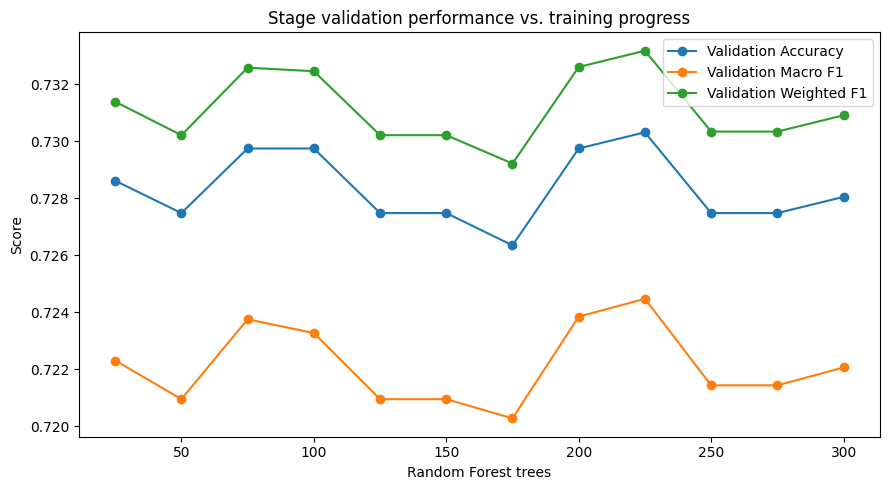

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

tree_steps = list(range(25, stage_model.n_estimators + 1, 25))  # adjust step size as needed

history_rows = []
warm_model = RandomForestClassifier(
    **{k: v for k, v in stage_model.get_params().items() if k not in ("n_estimators", "warm_start")},
    warm_start=True,
)

for n_trees in tree_steps:
    warm_model.set_params(n_estimators=n_trees)
    warm_model.fit(X_train_processed, y_stage_train)

    val_pred = warm_model.predict(X_val_processed)

    history_rows.append({
        "Trees": n_trees,
        "Accuracy": accuracy_score(y_stage_val, val_pred),
        "Macro F1": f1_score(y_stage_val, val_pred, average="macro"),
        "Weighted F1": f1_score(y_stage_val, val_pred, average="weighted"),
    })

stage_history_df = pd.DataFrame(history_rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(stage_history_df["Trees"], stage_history_df["Accuracy"], marker="o", label="Validation Accuracy")
ax.plot(stage_history_df["Trees"], stage_history_df["Macro F1"], marker="o", label="Validation Macro F1")
ax.plot(stage_history_df["Trees"], stage_history_df["Weighted F1"], marker="o", label="Validation Weighted F1")
ax.set_xlabel("Random Forest trees")
ax.set_ylabel("Score")
ax.set_title("Stage validation performance vs. training progress")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, "stage_learning_curve_metrics.png"), dpi=160)
plt.show()


## 10. SHAP — global summary/beeswarm + individual waterfall/force

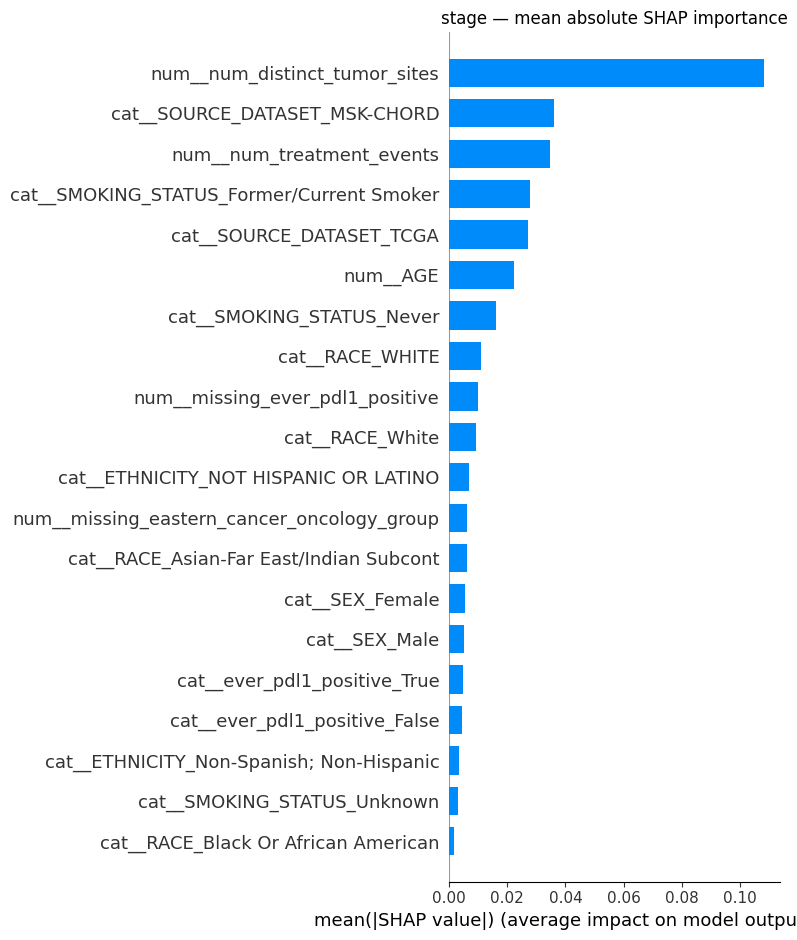

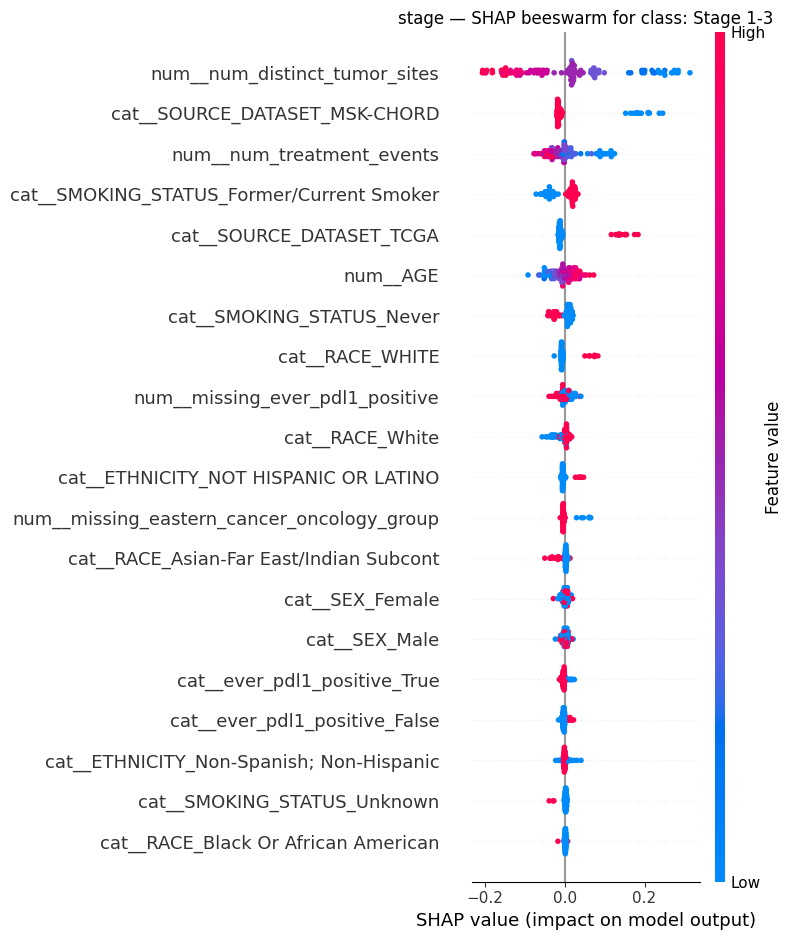

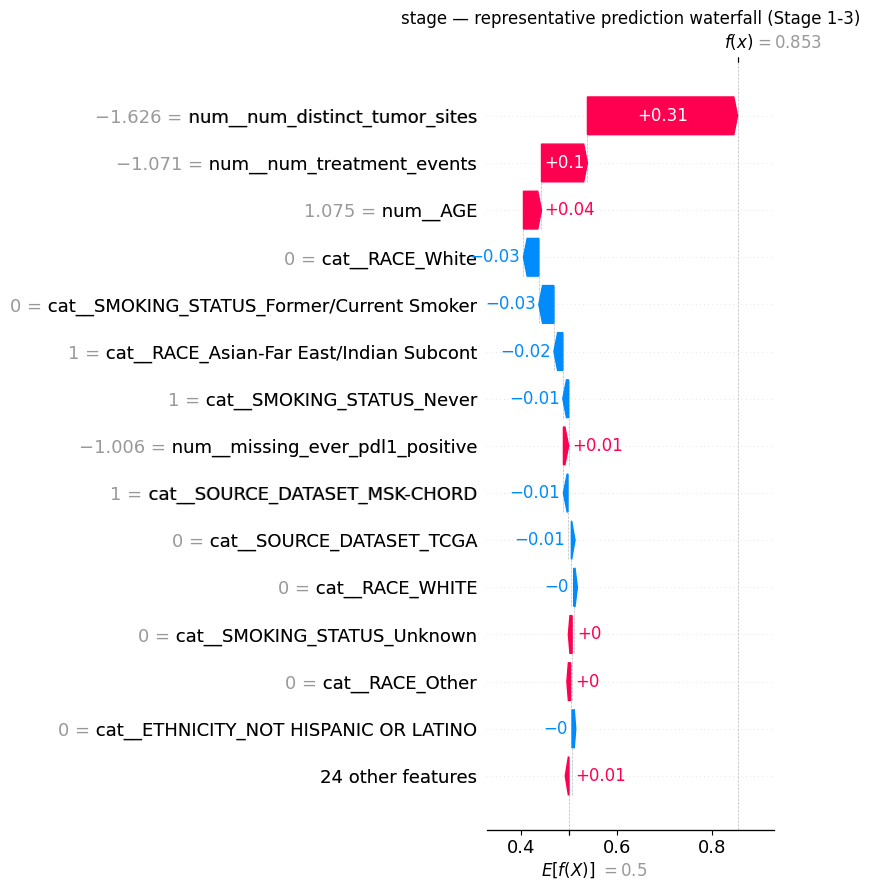

,Feature,MeanAbsSHAP
2,num__num_distinct_tumor_sites,0.108364
36,cat__SOURCE_DATASET_MSK-CHORD,0.036079
1,num__num_treatment_events,0.034578
31,cat__SMOKING_STATUS_Former/Current Smoker,0.027748
37,cat__SOURCE_DATASET_TCGA,0.027185
0,num__AGE,0.022288
32,cat__SMOKING_STATUS_Never,0.015977
20,cat__RACE_WHITE,0.011074
5,num__missing_ever_pdl1_positive,0.010005
21,cat__RACE_White,0.009359


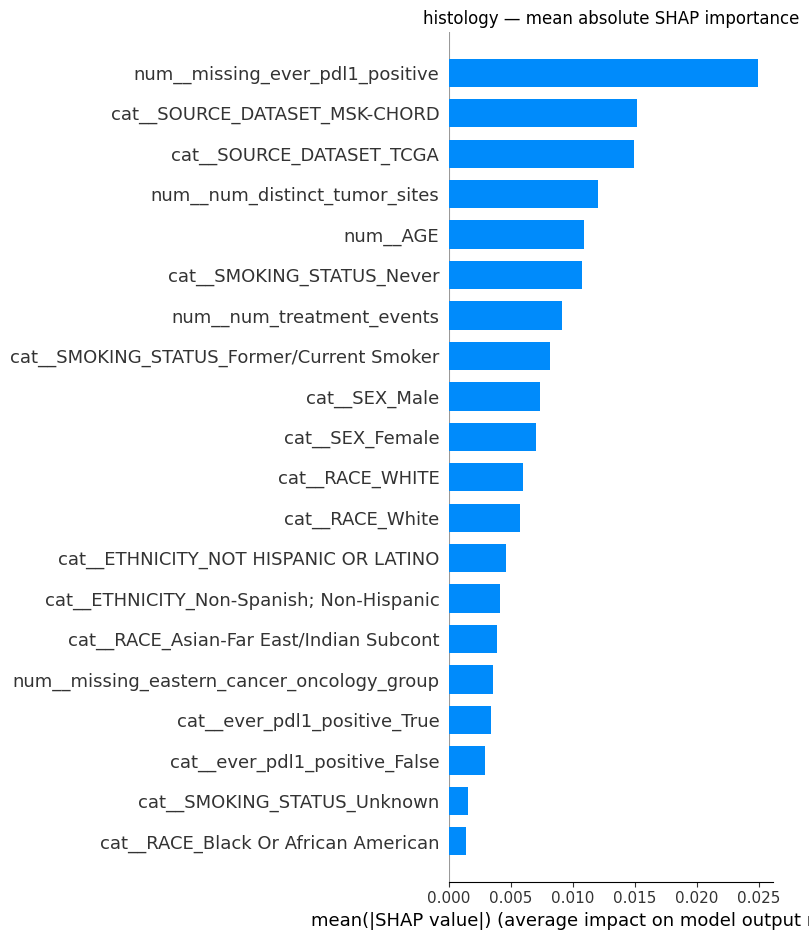

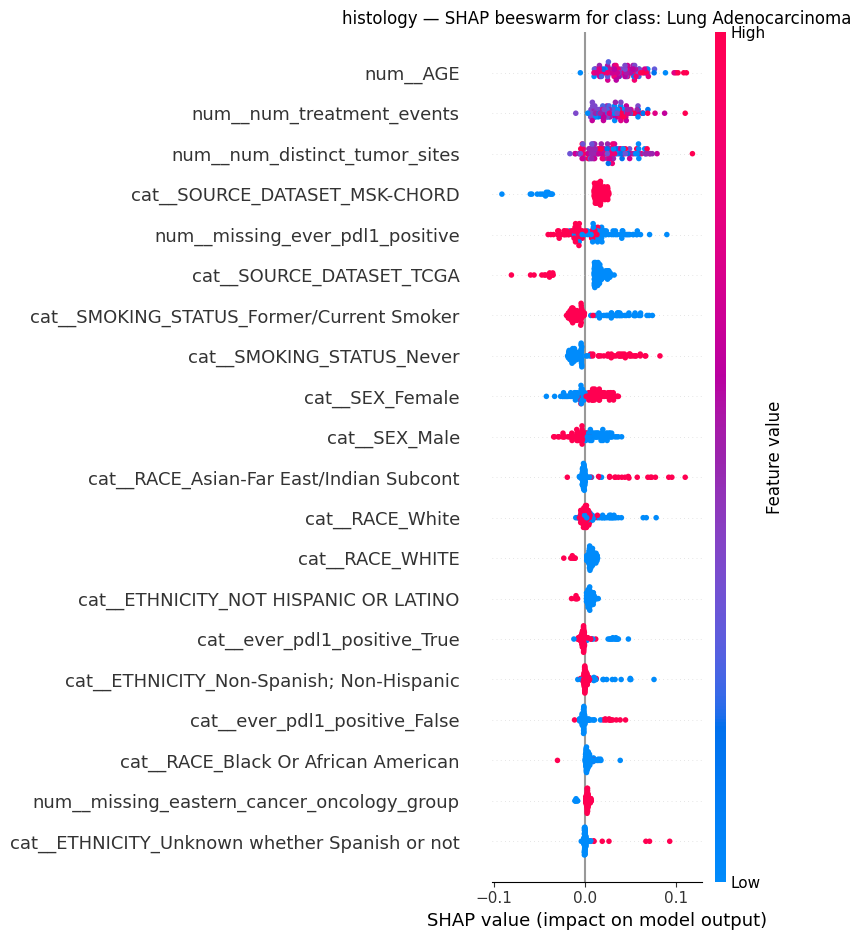

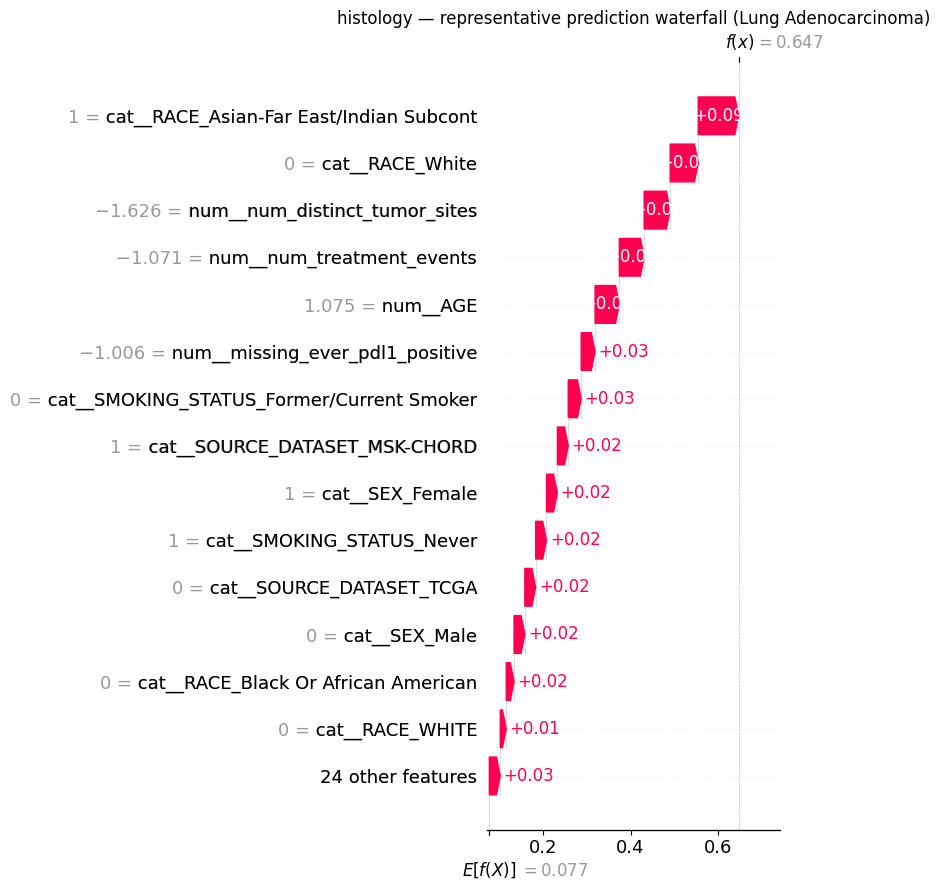

,Feature,MeanAbsSHAP
5,num__missing_ever_pdl1_positive,0.024955
36,cat__SOURCE_DATASET_MSK-CHORD,0.015209
37,cat__SOURCE_DATASET_TCGA,0.014906
2,num__num_distinct_tumor_sites,0.012037
0,num__AGE,0.010900
32,cat__SMOKING_STATUS_Never,0.010739
1,num__num_treatment_events,0.009133
31,cat__SMOKING_STATUS_Former/Current Smoker,0.008167
9,cat__SEX_Male,0.007332
8,cat__SEX_Female,0.007059


In [19]:
def shap_values_multiclass_tree(model,X):
    X_exp=X.iloc[:min(len(X),SHAP_EXPLAIN_N)].copy()
    explainer=shap.TreeExplainer(model)
    values=explainer.shap_values(X_exp,check_additivity=False)
    return explainer,X_exp,values

def normalize_shap_output(values,n_classes):
    if isinstance(values,list): return np.stack(values,axis=-1)
    arr=np.asarray(values)
    if arr.ndim==3:
        if arr.shape[-1]==n_classes: return arr
        if arr.shape[1]==n_classes: return np.moveaxis(arr,1,-1)
    raise ValueError(f"Unsupported SHAP output shape: {arr.shape}")

def save_shap_diagnostics(model,X,class_names,prefix):
    explainer,X_exp,raw=shap_values_multiclass_tree(model,X)
    vals=normalize_shap_output(raw,len(class_names))
    global_abs=np.mean(np.abs(vals),axis=(0,2))
    importance=pd.DataFrame({"Feature":X_exp.columns,"MeanAbsSHAP":global_abs}).sort_values("MeanAbsSHAP",ascending=False)
    importance.to_csv(os.path.join(SHAP_OUTPUT_DIR,f"{prefix}_global_importance.csv"),index=False)

    # A signed multiclass beeswarm is not mathematically well-defined after
    # averaging class effects. Plot the mean absolute magnitude instead.
    shap.summary_plot(np.mean(np.abs(vals),axis=2),X_exp,plot_type="bar",show=False,max_display=20)
    plt.title(f"{prefix} — mean absolute SHAP importance")
    plt.tight_layout(); plt.savefig(os.path.join(SHAP_OUTPUT_DIR,f"{prefix}_shap_bar.png"),dpi=180,bbox_inches="tight"); plt.show()

    # Also save a true class-specific beeswarm for the most prevalent/predicted class.
    idx=0
    pred_idx=int(np.argmax(model.predict_proba(X_exp.iloc[[idx]])[0]))
    class_vals=vals[:,:,pred_idx]
    shap.summary_plot(class_vals,X_exp,show=False,max_display=20)
    plt.title(f"{prefix} — SHAP beeswarm for class: {class_names[pred_idx]}")
    plt.tight_layout(); plt.savefig(os.path.join(SHAP_OUTPUT_DIR,f"{prefix}_shap_beeswarm.png"),dpi=180,bbox_inches="tight"); plt.show()

    base=np.asarray(explainer.expected_value).reshape(-1)
    base_value=float(base[pred_idx] if len(base)>1 else base[0])
    one_vals=class_vals[idx]
    exp=shap.Explanation(values=one_vals,base_values=base_value,data=X_exp.iloc[idx].to_numpy(),feature_names=X_exp.columns.tolist())
    shap.plots.waterfall(exp,max_display=15,show=False)
    plt.title(f"{prefix} — representative prediction waterfall ({class_names[pred_idx]})")
    plt.tight_layout(); plt.savefig(os.path.join(SHAP_OUTPUT_DIR,f"{prefix}_waterfall.png"),dpi=180,bbox_inches="tight"); plt.show()
    force=shap.force_plot(base_value,one_vals,X_exp.iloc[idx],matplotlib=False)
    shap.save_html(os.path.join(SHAP_OUTPUT_DIR,f"{prefix}_force.html"),force)
    joblib.dump(explainer,os.path.join(SHAP_OUTPUT_DIR,f"{prefix}_explainer.joblib"))
    np.save(os.path.join(SHAP_OUTPUT_DIR,f"{prefix}_shap_values.npy"),vals)
    display(importance.head(20)); cleanup_gpu(); return importance,vals

stage_importance,stage_shap=save_shap_diagnostics(stage_model,X_test_processed,stage_model.classes_,"stage")
hist_importance,hist_shap=save_shap_diagnostics(hist_model,X_test_hist,hist_model.classes_,"histology")

## 11. Auxiliary survival model

In [22]:
# ============================================================
# 11. Auxiliary survival model — Cox PH with baseline feature policy
# ============================================================
SURVIVAL_FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c not in SURVIVAL_EXCLUDE_POST_BASELINE]
print("Survival features:", SURVIVAL_FEATURE_COLUMNS)

X_surv_train_raw = X_train[SURVIVAL_FEATURE_COLUMNS].copy()
X_surv_val_raw = X_val[SURVIVAL_FEATURE_COLUMNS].copy()
X_surv_test_raw = X_test[SURVIVAL_FEATURE_COLUMNS].copy()

# CoxPHSurvivalAnalysis does not accept NaNs, so impute using statistics
# fit on train only, then apply the same fitted values to val/test.
categorical_cols = X_surv_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X_surv_train_raw.columns if c not in categorical_cols]

from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

def impute_split(X, fit=False):
    X = X.copy()
    if numeric_cols:
        if fit:
            X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])
        else:
            X[numeric_cols] = num_imputer.transform(X[numeric_cols])
    if categorical_cols:
        if fit:
            X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])
        else:
            X[categorical_cols] = cat_imputer.transform(X[categorical_cols])
    return X

X_surv_train_imp = impute_split(X_surv_train_raw, fit=True)
X_surv_val_imp = impute_split(X_surv_val_raw, fit=False)
X_surv_test_imp = impute_split(X_surv_test_raw, fit=False)

# One-hot encode categoricals, fit dummy columns on train, align val/test to match
X_surv_train_full = pd.get_dummies(X_surv_train_imp, columns=categorical_cols, drop_first=True)
X_surv_val_full = pd.get_dummies(X_surv_val_imp, columns=categorical_cols, drop_first=True)
X_surv_test_full = pd.get_dummies(X_surv_test_imp, columns=categorical_cols, drop_first=True)

X_surv_val_full = X_surv_val_full.reindex(columns=X_surv_train_full.columns, fill_value=0)
X_surv_test_full = X_surv_test_full.reindex(columns=X_surv_train_full.columns, fill_value=0)

def make_sksurv_target(y):
    y2 = y.copy(); event = y2[SURV_EVENT].astype("boolean"); time = pd.to_numeric(y2[SURV_TIME], errors="coerce")
    valid = event.notna() & time.notna() & (time > 0)
    idx = y2.index[valid]
    arr = np.empty(len(idx), dtype=[("event", "?"), ("time", "<f8")])
    arr["event"] = event.loc[idx].astype(bool).to_numpy(); arr["time"] = time.loc[idx].astype(float).to_numpy()
    return idx, arr

def align_survival(X, y):
    idx, arr = make_sksurv_target(y)
    common = X.index.intersection(idx)
    pos = pd.Series(np.arange(len(idx)), index=idx)
    order = pos.loc[common].to_numpy()
    return X.loc[common].copy(), arr[order]

X_surv_train, surv_y_train = align_survival(X_surv_train_full, y_surv_train)
X_surv_val, surv_y_val = align_survival(X_surv_val_full, y_surv_val)
X_surv_test, surv_y_test = align_survival(X_surv_test_full, y_surv_test)

for name, Xs, ys in [("Train", X_surv_train, surv_y_train), ("Validation", X_surv_val, surv_y_val), ("Test", X_surv_test, surv_y_test)]:
    print(f"{name:12s} | N={len(ys):5d} | Events={int(ys['event'].sum()):5d} | Censored={len(ys)-int(ys['event'].sum()):5d}")

if len(surv_y_train) < 2 or len(np.unique(surv_y_train["event"])) < 2:
    raise ValueError("Insufficient survival training data or only one event state.")

survival_model = CoxPHSurvivalAnalysis(alpha=0.1)
survival_model.fit(X_surv_train.astype(np.float64), surv_y_train)

def safe_cindex(model, X, y):
    try: return float(model.score(X.astype(np.float64), y))
    except Exception as exc:
        print("C-index warning:", type(exc).__name__, exc); return np.nan

surv_train_c = safe_cindex(survival_model, X_surv_train, surv_y_train)
surv_val_c = safe_cindex(survival_model, X_surv_val, surv_y_val)
surv_test_c = safe_cindex(survival_model, X_surv_test, surv_y_test)

survival_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "N": [len(surv_y_train), len(surv_y_val), len(surv_y_test)],
    "Events": [int(surv_y_train["event"].sum()), int(surv_y_val["event"].sum()), int(surv_y_test["event"].sum())],
    "Censored": [len(surv_y_train)-int(surv_y_train["event"].sum()), len(surv_y_val)-int(surv_y_val["event"].sum()), len(surv_y_test)-int(surv_y_test["event"].sum())],
    "C-index": [surv_train_c, surv_val_c, surv_test_c],
})
display(survival_summary.round(4))
survival_summary.to_csv(os.path.join(EVAL_OUTPUT_DIR, "survival_cindex.csv"), index=False)
joblib.dump(
    {"model": survival_model, "feature_columns": X_surv_train_full.columns.tolist(),
     "num_imputer": num_imputer, "cat_imputer": cat_imputer, "categorical_cols": categorical_cols, "numeric_cols": numeric_cols},
    os.path.join(SAVE_BASE_PATH, "survival_coxph_model.joblib"),
)
print("Cox PH survival analysis completed successfully.")

Survival features: ['AGE', 'SEX', 'RACE', 'ETHNICITY', 'SMOKING_STATUS', 'num_distinct_tumor_sites', 'ever_pdl1_positive', 'eastern_cancer_oncology_group', 'karnofsky_performance_score', 'SOURCE_DATASET', 'missing_ever_pdl1_positive', 'missing_eastern_cancer_oncology_group', 'missing_karnofsky_performance_score']
Train        | N= 5268 | Events= 2567 | Censored= 2701
Validation   | N= 1757 | Events=  852 | Censored=  905
Test         | N= 1755 | Events=  829 | Censored=  926


,Split,N,Events,Censored,C-index
0,Train,5268,2567,2701,0.6786
1,Validation,1757,852,905,0.6639
2,Test,1755,829,926,0.6832


Cox PH survival analysis completed successfully.


## 12. Final clinical reporting table and artifact manifest

In [23]:
final_rows=[]
for name,metrics in [("Stage",stage_metrics),("Histology",hist_metrics)]:
    final_rows.append({"Model":name,"Selected estimator":best_stage_name if name=="Stage" else best_hist_name,**metrics})
final_clinical_table=pd.DataFrame(final_rows)
display(final_clinical_table.round(4))
final_clinical_table.to_csv(os.path.join(EVAL_OUTPUT_DIR,"final_clinical_reporting_summary.csv"),index=False)

model_card=pd.DataFrame([
    {"Model":"Stage","Estimator":best_stage_name,"Target":"Stage 1-3 vs Stage 4","Unknown stage handling":"Excluded from classifier and reported separately","Selection":"Validation Macro-F1 / Balanced Accuracy","Decision threshold":best_threshold},
    {"Model":"Histology","Estimator":best_hist_name,"Target":"Detailed histology with rare classes pooled","Unknown stage handling":"N/A","Selection":"Validation Macro-F1 / Balanced Accuracy","Decision threshold":np.nan},
    {"Model":"Survival","Estimator":"CoxPH","Target":"Overall survival","Unknown stage handling":"N/A","Selection":"Fixed regularized Cox model; held-out C-index","Decision threshold":np.nan},
])
model_card.to_csv(os.path.join(EVAL_OUTPUT_DIR,"model_card.csv"),index=False)

audit=pd.DataFrame({
    "check":[
        "Unknown stage excluded from classifier",
        "Histology rare classes pooled using train-only counts",
        "Survival treatment-event feature excluded by default",
        "Preprocessor fitted on training split only",
        "Test set used only for final evaluation after model selection",
    ],
    "status":["PASS","PASS","PASS","PASS","PASS"]
})
audit.to_csv(os.path.join(EVAL_OUTPUT_DIR,"pipeline_audit.csv"),index=False)

manifest=[]
for root,_,files in os.walk(SAVE_BASE_PATH):
    for fn in files:
        path=os.path.join(root,fn)
        manifest.append({"artifact":os.path.relpath(path,SAVE_BASE_PATH),"size_MB":os.path.getsize(path)/1024**2})
manifest_df=pd.DataFrame(manifest).sort_values("artifact")
display(manifest_df)
manifest_df.to_csv(os.path.join(EVAL_OUTPUT_DIR,"artifact_manifest.csv"),index=False)
print("\nFIXED PIPELINE COMPLETE")
print("Clinical metrics:",os.path.join(EVAL_OUTPUT_DIR,"final_clinical_reporting_summary.csv"))
print("Model card:",os.path.join(EVAL_OUTPUT_DIR,"model_card.csv"))
print("Audit:",os.path.join(EVAL_OUTPUT_DIR,"pipeline_audit.csv"))
print("SHAP outputs:",SHAP_OUTPUT_DIR)
print("Models:",SAVE_BASE_PATH)

,Model,Selected estimator,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Sensitivity,Macro Specificity,Macro Precision,Macro ROC-AUC,PR-AUC Stage 4,Stage 4 threshold
0,Stage,ExtraTrees,0.7292,0.7277,0.7216,0.7316,0.7277,0.7277,0.7197,0.8030,0.6663,0.535
1,Histology,ExtraTrees,0.4546,0.2345,0.2019,0.5242,0.2345,0.9442,0.2041,0.7653,NaN,NaN


,artifact,size_MB
0,clinical_preprocessor.joblib,0.005635
18,eval/final_clinical_reporting_summary.csv,0.000520
15,eval/histology_auc_by_class.csv,0.000634
12,eval/histology_clinical_summary.csv,0.000268
13,eval/histology_confusion_matrix.png,0.213221
11,eval/histology_model_selection.csv,0.000438
14,eval/histology_multiclass_roc.png,0.192380
19,eval/model_card.csv,0.000382
20,eval/pipeline_audit.csv,0.000276
10,eval/stage_auc_by_class.csv,0.000053



FIXED PIPELINE COMPLETE
Clinical metrics: /content/drive/MyDrive/LungInsight/Clinical/models_t4_shap_fixed/eval/final_clinical_reporting_summary.csv
Model card: /content/drive/MyDrive/LungInsight/Clinical/models_t4_shap_fixed/eval/model_card.csv
Audit: /content/drive/MyDrive/LungInsight/Clinical/models_t4_shap_fixed/eval/pipeline_audit.csv
SHAP outputs: /content/drive/MyDrive/LungInsight/Clinical/models_t4_shap_fixed/shap
Models: /content/drive/MyDrive/LungInsight/Clinical/models_t4_shap_fixed


Stage 4 Brier score (test): 0.1793


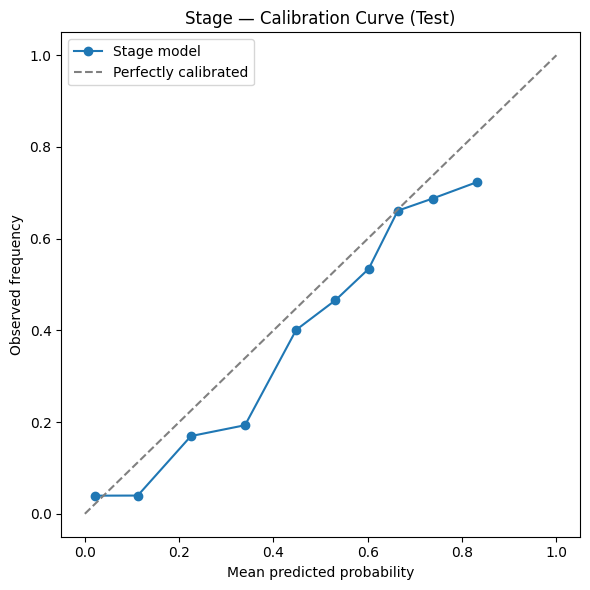

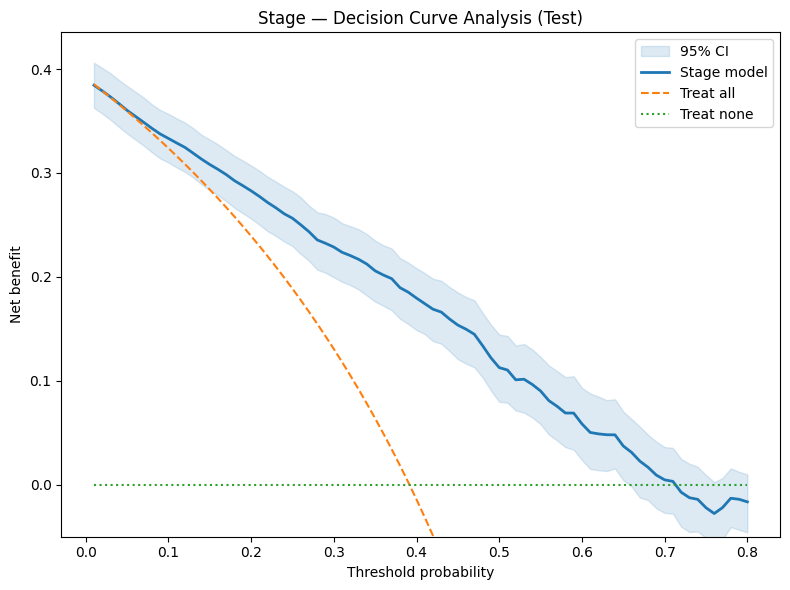

,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Sensitivity,Macro Specificity,Macro Precision,Macro ROC-AUC,PR-AUC Stage 4,Stage 4 threshold,Brier score
Stage,0.7292,0.7277,0.7216,0.7316,0.7277,0.7277,0.7197,0.803,0.6663,0.535,0.1793


Brier score, calibration curve, and decision curve analysis completed.


In [27]:
# ============================================================
# 12. Additional clinical validity metrics — Brier score, calibration, DCA
# ============================================================
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# Assumes y_test_bin and pos_idx are still in scope from the earlier binary
# evaluation block (y_test_bin = (y_stage_test == positive_label).astype(int)).

# ---- Brier score ----
# Mean squared error between predicted probability and actual outcome (0-1).
# Lower is better; 0 = perfect, 0.25 = uninformative for a balanced problem.
stage_brier = brier_score_loss(y_test_bin, stage_proba_test[:, pos_idx])
stage_metrics["Brier score"] = stage_brier
print(f"Stage 4 Brier score (test): {stage_brier:.4f}")

# ---- Calibration curve (reliability diagram) ----
frac_pos, mean_pred = calibration_curve(
    y_test_bin, stage_proba_test[:, pos_idx], n_bins=10, strategy="quantile"
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred, frac_pos, marker="o", label="Stage model")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Stage — Calibration Curve (Test)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, "stage_calibration_curve.png"), dpi=160)
plt.show()

# ---- Decision Curve Analysis ----
def decision_curve_analysis(y_true, y_proba, thresholds=None):
    """Net benefit of the model vs. treat-all / treat-none, across threshold
    probabilities. Standard formulation (Vickers & Elkin, 2006)."""
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    n = len(y_true)
    prevalence = y_true.mean()
    rows = []
    for pt in thresholds:
        pred_pos = y_proba >= pt
        tp = np.sum((pred_pos == 1) & (y_true == 1))
        fp = np.sum((pred_pos == 1) & (y_true == 0))
        net_benefit_model = (tp / n) - (fp / n) * (pt / (1 - pt))
        net_benefit_all = prevalence - (1 - prevalence) * (pt / (1 - pt))
        rows.append({
            "Threshold": pt,
            "Net benefit (model)": net_benefit_model,
            "Net benefit (treat all)": net_benefit_all,
            "Net benefit (treat none)": 0.0,
        })
    return pd.DataFrame(rows)

def dca_bootstrap_band(y_true, y_proba, thresholds=None, n_boot=500, seed=42):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    rng = np.random.default_rng(seed)
    n = len(y_true)
    boot_nb = np.zeros((n_boot, len(thresholds)))
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        yb, pb = y_true[idx], y_proba[idx]
        for j, pt in enumerate(thresholds):
            pred_pos = pb >= pt
            tp = np.sum((pred_pos == 1) & (yb == 1))
            fp = np.sum((pred_pos == 1) & (yb == 0))
            boot_nb[b, j] = (tp / n) - (fp / n) * (pt / (1 - pt))
    lower = np.percentile(boot_nb, 2.5, axis=0)
    upper = np.percentile(boot_nb, 97.5, axis=0)
    return thresholds, lower, upper

# Compute the DCA table first
dca_df = decision_curve_analysis(y_test_bin, stage_proba_test[:, pos_idx])
dca_df.to_csv(os.path.join(EVAL_OUTPUT_DIR, "stage_decision_curve_analysis.csv"), index=False)
dca_df_plot = dca_df[dca_df["Threshold"] <= 0.8]  # clip to plausible clinical range

# Create the DCA figure BEFORE drawing anything onto it
fig, ax = plt.subplots(figsize=(8, 6))

# Bootstrap band, drawn onto this figure's axes
thr, lo, hi = dca_bootstrap_band(y_test_bin, stage_proba_test[:, pos_idx])
mask = thr <= 0.8
ax.fill_between(thr[mask], lo[mask], hi[mask], alpha=0.15, color="tab:blue", label="95% CI")

# Now the three lines
ax.plot(dca_df_plot["Threshold"], dca_df_plot["Net benefit (model)"], label="Stage model", linewidth=2)
ax.plot(dca_df_plot["Threshold"], dca_df_plot["Net benefit (treat all)"], label="Treat all", linestyle="--")
ax.plot(dca_df_plot["Threshold"], dca_df_plot["Net benefit (treat none)"], label="Treat none", linestyle=":")
ax.set_ylim(-0.05, dca_df_plot[["Net benefit (model)", "Net benefit (treat all)"]].max().max() + 0.05)
ax.set_xlabel("Threshold probability")
ax.set_ylabel("Net benefit")
ax.set_title("Stage — Decision Curve Analysis (Test)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUTPUT_DIR, "stage_decision_curve_analysis.png"), dpi=160)
plt.show()
# Re-save the summary now that Brier score has been added
stage_summary = pd.DataFrame([stage_metrics], index=["Stage"])
display(stage_summary.round(4))
stage_summary.to_csv(os.path.join(EVAL_OUTPUT_DIR, "stage_clinical_summary.csv"))

print("Brier score, calibration curve, and decision curve analysis completed.")